# Heart Disease UCI Dataset — Exploratory Data Analysis

This notebook performs data acquisition, cleaning, and exploratory analysis
of the Heart Disease UCI dataset as required by **Task 1** of the MLOps Assignment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Data Acquisition & Loading

In [2]:
DATA_PATH = Path("../data/heart.csv")
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Basic Info & Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing: 6


In [5]:
# Handle missing values (median for numeric, mode for categorical)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing after cleaning: {df.isnull().sum().sum()}")

Missing after cleaning: 0


## 3. Statistical Summary

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 4. Target Class Balance

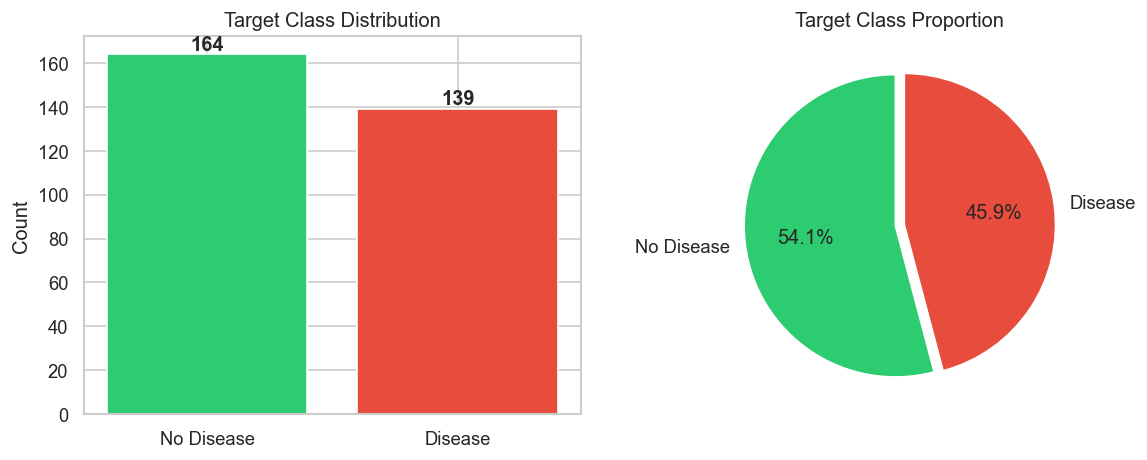

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index.map({0: 'No Disease', 1: 'Disease'}), counts.values, color=colors)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.03, 0.03))
axes[1].set_title('Target Class Proportion')

plt.tight_layout()
plt.savefig('../screenshots/class_balance.png', bbox_inches='tight')
plt.show()

## 5. Feature Distributions (Histograms)

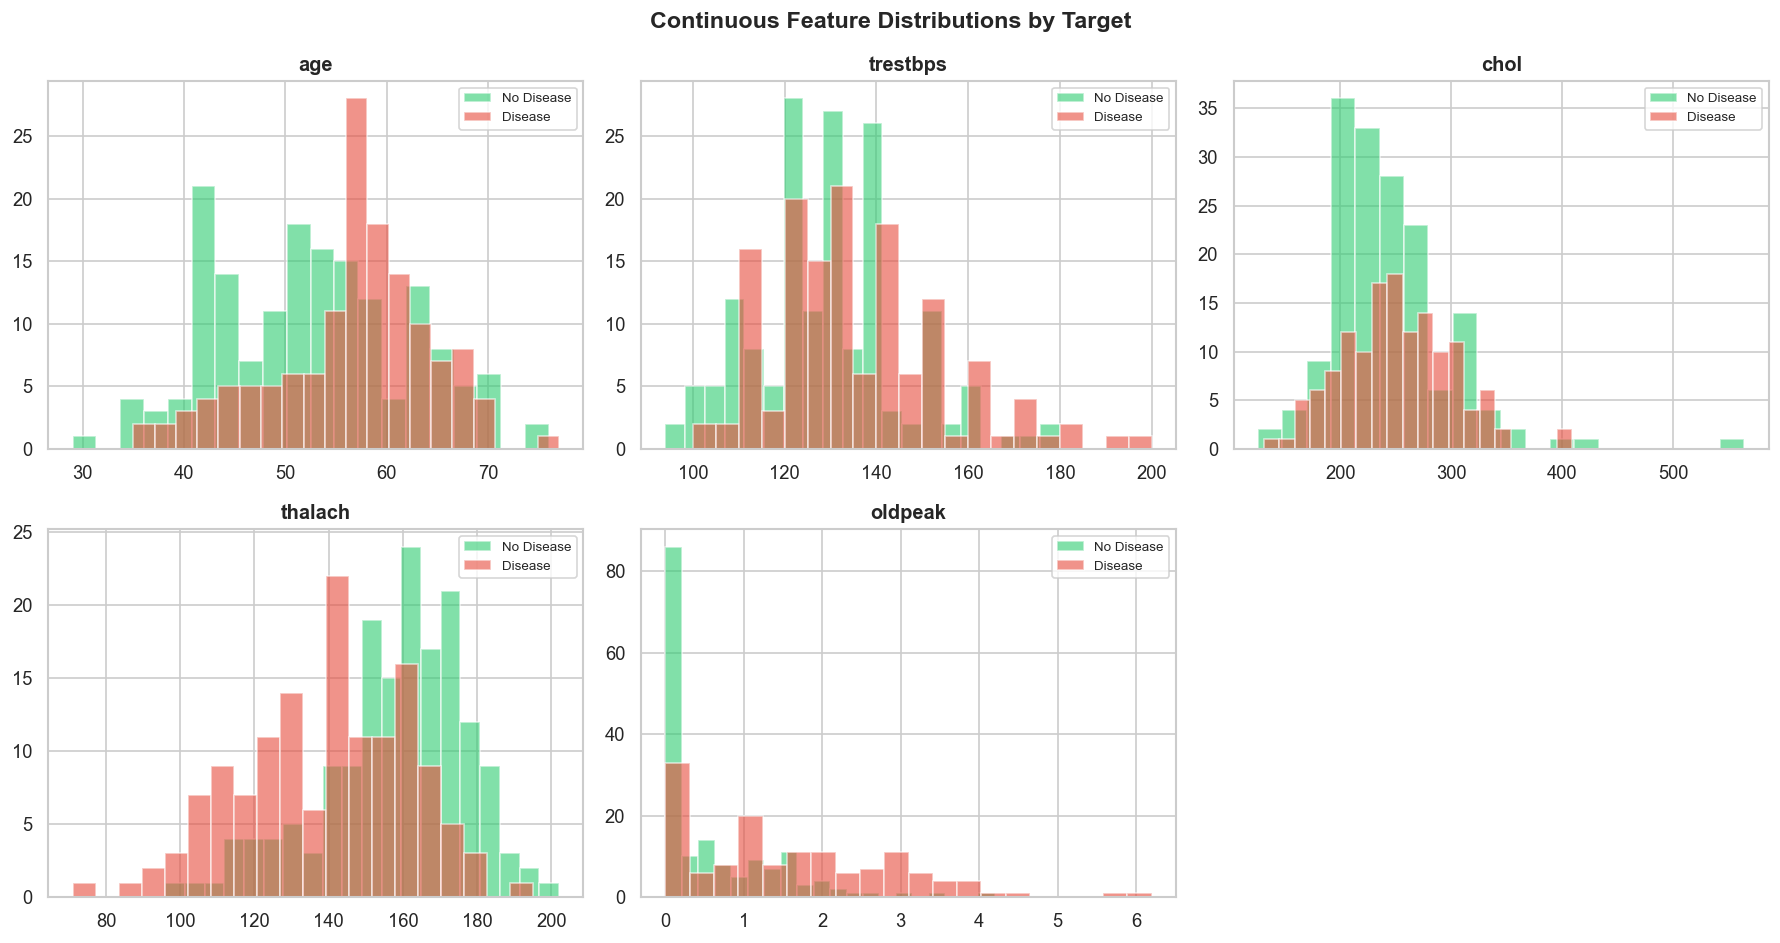

In [8]:
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        subset = df[df['target'] == label]
        ax.hist(subset[col], bins=20, alpha=0.6, color=color,
                label='No Disease' if label == 0 else 'Disease')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Continuous Feature Distributions by Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/feature_histograms.png', bbox_inches='tight')
plt.show()

## 6. Categorical Feature Analysis

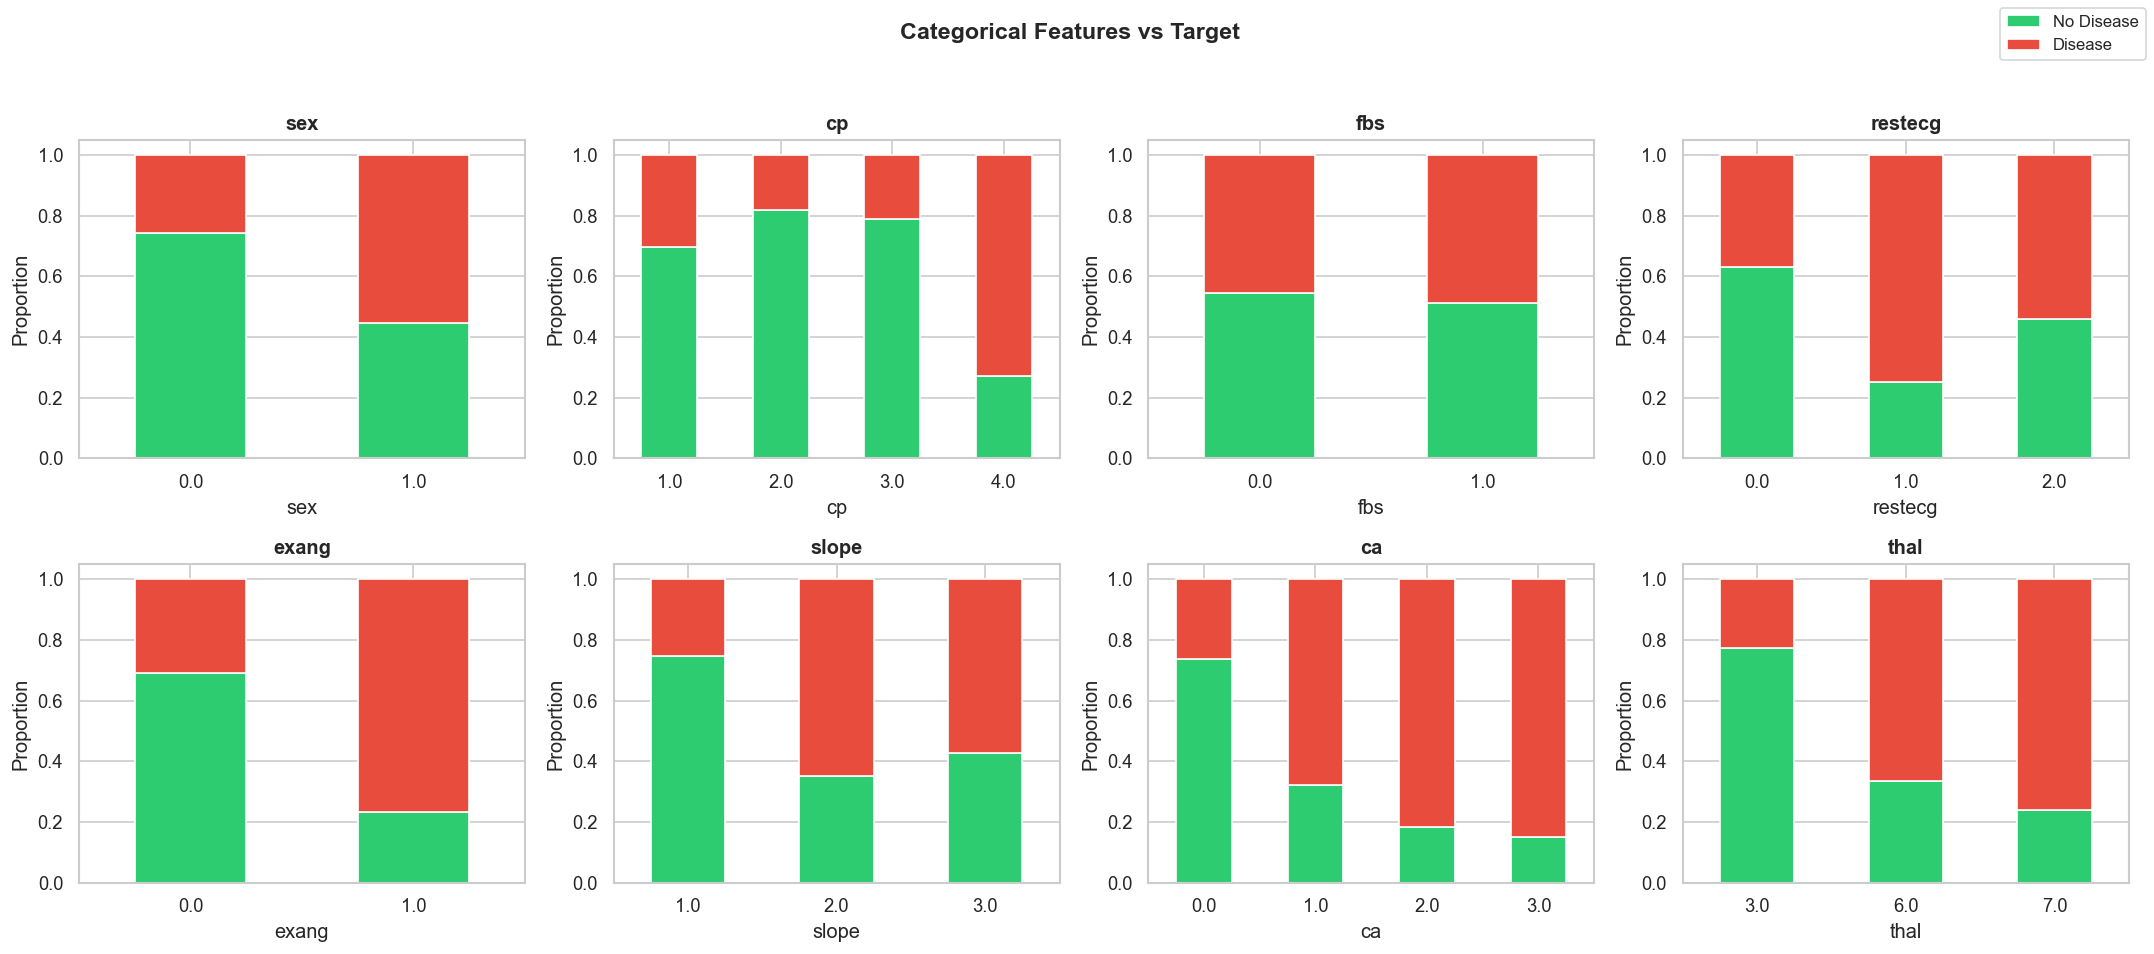

In [9]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['target'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], legend=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No Disease', 'Disease'], loc='upper right', fontsize=10)
plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../screenshots/categorical_features.png', bbox_inches='tight')
plt.show()

## 7. Correlation Heatmap

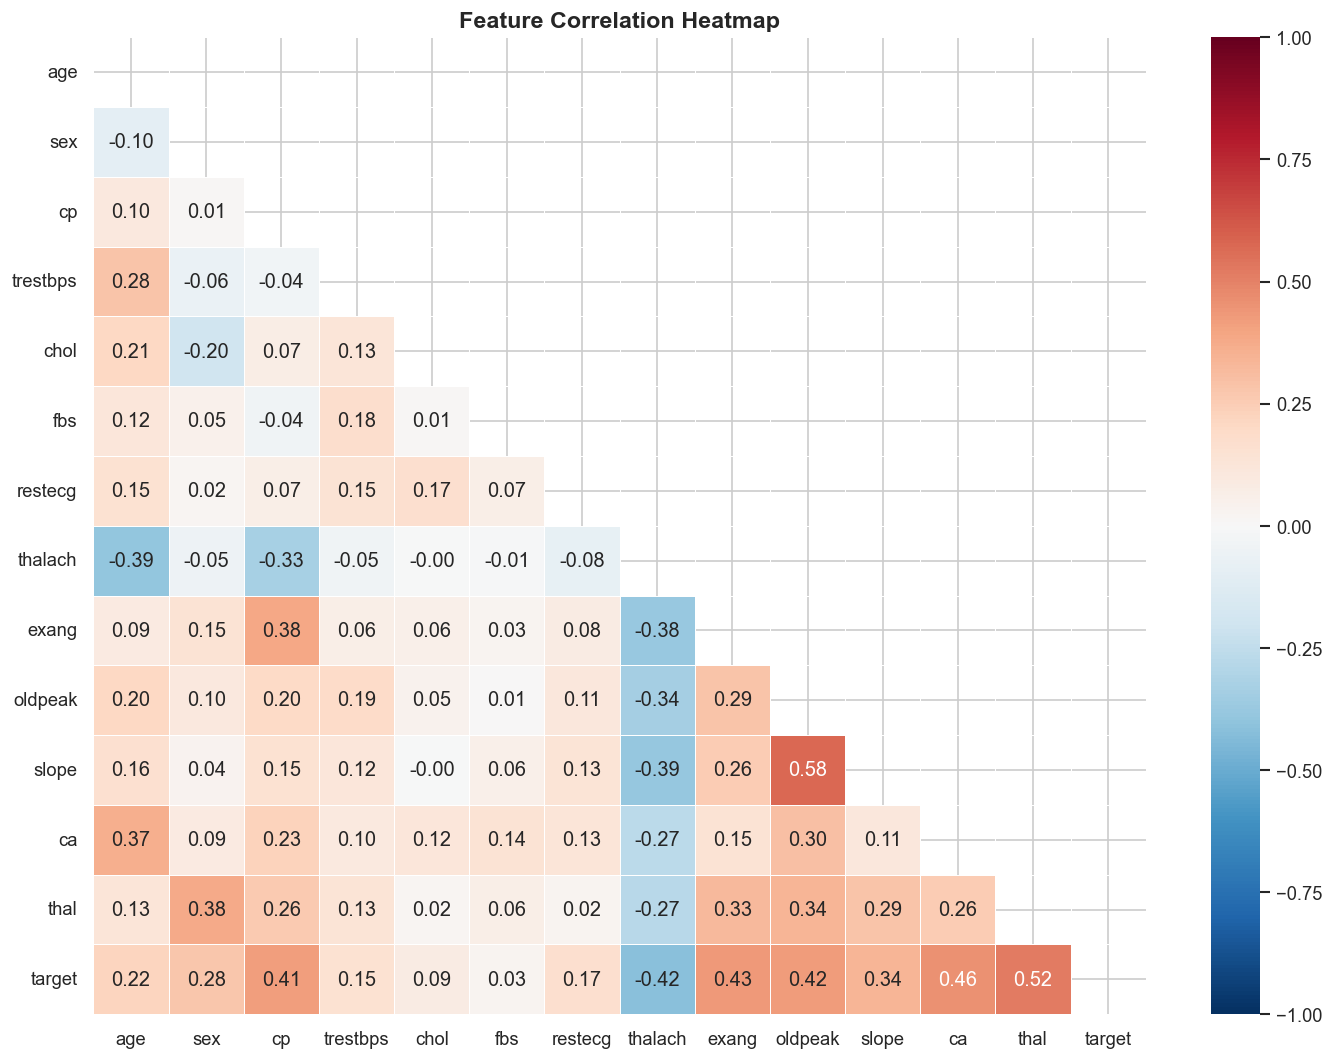

In [10]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 8. Box Plots — Outlier Detection

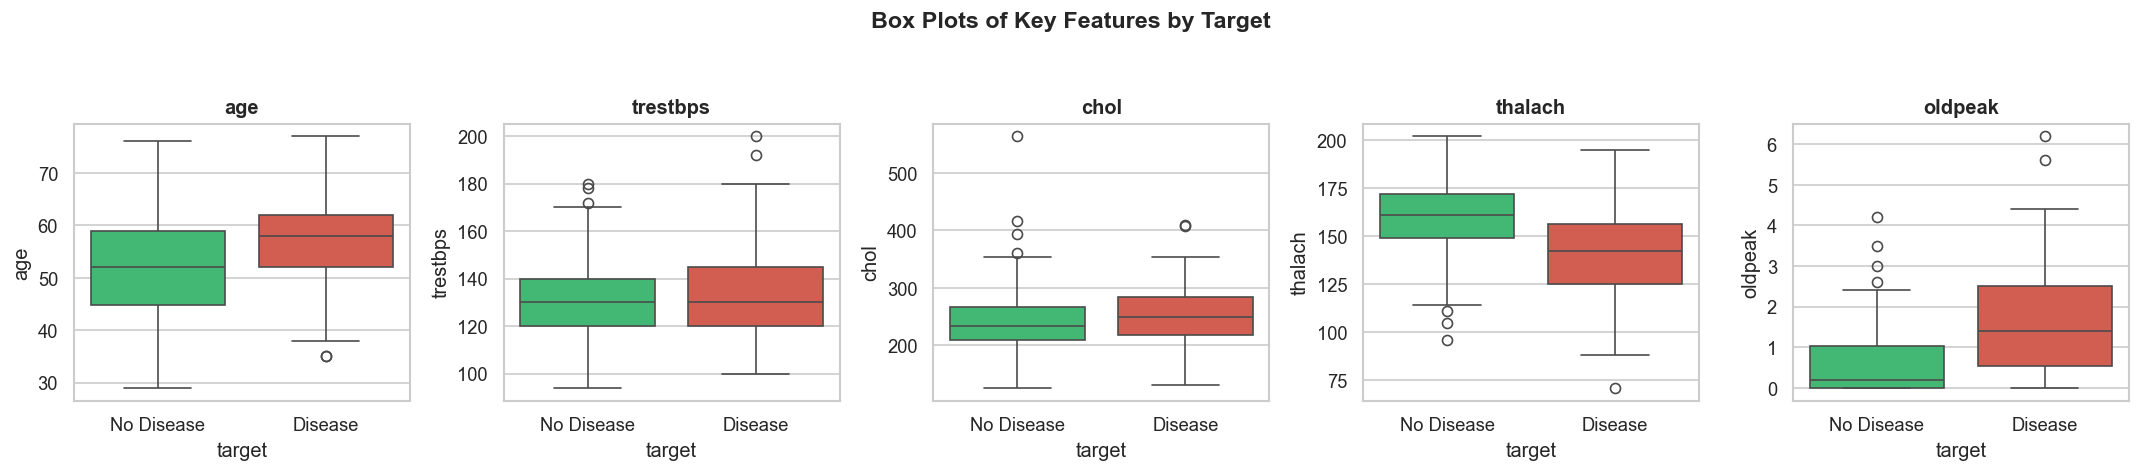

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(features):
    sns.boxplot(data=df, x='target', y=col, ax=axes[i], hue='target',
    palette={0: '#2ecc71', 1: '#e74c3c'}, legend=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Box Plots of Key Features by Target', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../screenshots/boxplots.png', bbox_inches='tight')
plt.show()

## 9. Key EDA Findings

1. **Class Balance**: The dataset is roughly balanced between disease and no-disease classes.
2. **Chest Pain Type (`cp`)**: Strongly associated with heart disease — type 0 (typical angina) has lower disease rate.
3. **Thalach (Max Heart Rate)**: Patients with heart disease tend to have lower max heart rates.
4. **Oldpeak (ST Depression)**: Higher values are associated with heart disease.
5. **Correlation**: `cp`, `thalach`, `slope`, and `exang` show the strongest correlations with the target.
6. **No missing values** were found in the dataset.